# Part 2: RFM Segmentation & Retention Strategy
## D2C Personal Care Brand — Customer Churn Intelligence

**Objective:**  
Build a multi-signal customer segmentation system using RFM scores enriched with support, behavioural, and campaign data. Assign each customer to a named segment and recommend targeted retention actions.

**Approach:**
1. Compute RFM features from order history (snapshot-safe)
2. Score and rank each dimension on a 1–5 quintile scale
3. Enrich with 4 non-RFM signals: support tickets, return rate, session activity, discount usage
4. Assign segments using rule-based logic
5. Validate segments with churn labels
6. Export `segments.csv`

---
## 0. Setup & Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from datetime import timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

os.makedirs('outputs', exist_ok=True)
os.makedirs('charts', exist_ok=True)

PALETTE = {
    'Champions':           '#1565C0',
    'Loyal Customers':     '#2E7D32',
    'Promising':           '#00ACC1',
    'At-Risk High Value':  '#F57F17',
    'Discount Seekers':    '#AD1457',
    'High Value Unhappy':  '#6A1B9A',
    'Dormant':             '#616161',
    'New Customers':       '#0288D1'
}
COLOR_LIST = list(PALETTE.values())

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Setup complete.')

Setup complete.


---
## 1. Data Loading

In [27]:
DATA_DIR = 'data'

def load_csv(filename, **kwargs):
    path = os.path.join(DATA_DIR, filename)
    try:
        df = pd.read_csv(path, **kwargs)
        print(f'  ✓  {filename:<35} {df.shape[0]:>8,} rows  ×  {df.shape[1]} cols')
        return df
    except FileNotFoundError:
        print(f'  ✗  {filename} NOT FOUND')
        return pd.DataFrame()

print('Loading datasets...')
customers  = load_csv('customers.csv')
orders     = load_csv('orders.csv')
tickets    = load_csv('support_tickets.csv')
events     = load_csv('web_events_snapshot.csv')
churn      = load_csv('churn_labels.csv')
campaigns  = load_csv('intervention_history.csv')
print('Done.')

Loading datasets...
  ✓  customers.csv                          2,400 rows  ×  9 cols
  ✓  orders.csv                            10,009 rows  ×  10 cols
  ✓  support_tickets.csv                    1,921 rows  ×  8 cols
  ✓  web_events_snapshot.csv                2,400 rows  ×  10 cols
  ✓  churn_labels.csv                       2,400 rows  ×  4 cols
  ✓  intervention_history.csv               2,400 rows  ×  5 cols
Done.


---
## 2. Column Detection & Snapshot Date

Auto-detect key column names across datasets so the notebook works regardless of minor naming variations.

In [28]:
# ── Auto-detect column names ──────────────────────────────────────────────────
def find_col(df, keywords, exclude=None):
    """Find first column matching any keyword (case-insensitive)."""
    exclude = exclude or []
    for col in df.columns:
        col_l = col.lower()
        if any(k in col_l for k in keywords) and not any(e in col_l for e in exclude):
            return col
    return None

# customers
CUST_ID   = find_col(customers, ['customer_id', 'customer id', 'cust_id'])
SIGNUP    = find_col(customers, ['signup', 'join', 'created', 'registration'])
TIER      = find_col(customers, ['tier', 'membership', 'level'])
CHANNEL   = find_col(customers, ['channel', 'acquisition', 'source'])

# orders
ORD_CUST  = find_col(orders,    ['customer_id', 'customer id', 'cust_id'])
ORD_ID    = find_col(orders,    ['order_id', 'order id'])
ORD_DATE  = find_col(orders,    ['order_date', 'order date', 'created', 'date', 'timestamp'])
ORD_AMT   = find_col(orders,    ['amount', 'value', 'revenue', 'total', 'price'])
ORD_DISC  = find_col(orders,    ['discount', 'promo', 'coupon'])
ORD_RET   = find_col(orders,    ['return', 'refund', 'returned'])

# support tickets
TKT_CUST  = find_col(tickets,   ['customer_id', 'customer id', 'cust_id'])
TKT_DATE  = find_col(tickets,   ['open', 'created', 'date', 'raised'])
TKT_ISSUE = find_col(tickets,   ['issue', 'type', 'category', 'reason'])
TKT_RESOL = find_col(tickets,   ['resolv', 'closed', 'status'])
TKT_CSAT  = find_col(tickets,   ['csat', 'satisfaction', 'rating', 'score'])

# events
EVT_CUST  = find_col(events,    ['customer_id', 'customer id', 'cust_id'])
EVT_SESS  = find_col(events,    ['session'])
EVT_DATE  = find_col(events,    ['date', 'timestamp', 'time'])

# campaigns
CMP_CUST  = find_col(campaigns, ['customer_id', 'customer id', 'cust_id'])
CMP_RESP  = find_col(campaigns, ['response', 'clicked', 'opened', 'engaged'])
CMP_DISC  = find_col(campaigns, ['discount', 'offer', 'promo'])

# churn
CHN_CUST  = find_col(churn,     ['customer_id', 'customer id', 'cust_id'])
CHN_LABEL = find_col(churn,     ['churn', 'label', 'churned'])
CHN_SNAP  = find_col(churn,     ['snapshot', 'date', 'as_of'])

print('Column mapping:')
print(f'  CUST_ID={CUST_ID}  ORD_DATE={ORD_DATE}  ORD_AMT={ORD_AMT}')
print(f'  TKT_CUST={TKT_CUST}  EVT_SESS={EVT_SESS}  CHN_LABEL={CHN_LABEL}')
print(f'  ORD_DISC={ORD_DISC}  ORD_RET={ORD_RET}  CMP_RESP={CMP_RESP}')

Column mapping:
  CUST_ID=customer_id  ORD_DATE=order_date  ORD_AMT=gross_amount
  TKT_CUST=customer_id  EVT_SESS=sessions_30d  CHN_LABEL=churn_next_60d
  ORD_DISC=discount_pct  ORD_RET=returned  CMP_RESP=None


In [29]:
# ── Snapshot date (use churn label date or max order date) ────────────────────
if not churn.empty and CHN_SNAP and churn[CHN_SNAP].notna().any():
    churn[CHN_SNAP] = pd.to_datetime(churn[CHN_SNAP], errors='coerce')
    SNAPSHOT_DATE = churn[CHN_SNAP].max()
else:
    orders[ORD_DATE] = pd.to_datetime(orders[ORD_DATE], errors='coerce')
    SNAPSHOT_DATE = orders[ORD_DATE].max()

print(f'Snapshot date (reference for recency): {SNAPSHOT_DATE.date()}')
print('All RFM features will be computed using data on or before this date.')

Snapshot date (reference for recency): 2025-09-30
All RFM features will be computed using data on or before this date.


---
## 3. RFM Feature Engineering

**Recency:** Days since last order (lower = more recent = better)  
**Frequency:** Total number of orders  
**Monetary:** Total spend (sum of order amounts)

In [30]:
# ── Parse dates & filter to snapshot ─────────────────────────────────────────
orders[ORD_DATE] = pd.to_datetime(orders[ORD_DATE], errors='coerce')
orders_clean = orders[orders[ORD_DATE] <= SNAPSHOT_DATE].copy()
print(f'Orders up to snapshot: {len(orders_clean):,} / {len(orders):,}')

# Remove negative or zero amounts (returns logged as negative)
if ORD_AMT:
    orders_clean = orders_clean[orders_clean[ORD_AMT] > 0].copy()
    print(f'After removing non-positive amounts: {len(orders_clean):,}')

Orders up to snapshot: 8,137 / 10,009
After removing non-positive amounts: 8,137


In [31]:
# ── Build RFM table ───────────────────────────────────────────────────────────
agg_dict = {
    'last_order_date': (ORD_DATE, 'max'),
    'frequency':       (ORD_ID if ORD_ID else ORD_CUST, 'count'),
}
if ORD_AMT:
    agg_dict['monetary'] = (ORD_AMT, 'sum')
    agg_dict['avg_order_value'] = (ORD_AMT, 'mean')

rfm = orders_clean.groupby(ORD_CUST).agg(**agg_dict).reset_index()
rfm.rename(columns={ORD_CUST: CUST_ID}, inplace=True)

# Recency in days
rfm['recency_days'] = (SNAPSHOT_DATE - rfm['last_order_date']).dt.days

print(f'RFM base table: {rfm.shape}')
display(rfm.describe())

RFM base table: (2400, 6)


,last_order_date,frequency,monetary,avg_order_value,recency_days
count,2400,2400.000,2400.000,2400.000,2400.000
mean,2025-07-04 14:58:48,3.390,2549.656,753.602,87.376
min,2024-03-17 00:00:00,1.000,149.000,149.000,0.000
25%,2025-05-24 00:00:00,1.000,955.380,530.102,25.000
50%,2025-07-26 00:00:00,3.000,2012.020,681.786,66.000
75%,2025-09-05 00:00:00,5.000,3566.080,896.338,129.000
max,2025-09-30 00:00:00,16.000,27215.920,8685.763,562.000
std,NaN,2.383,2129.104,381.117,80.137


In [32]:
# ── Quintile scoring (1=worst, 5=best) ───────────────────────────────────────
def quintile_score(series, ascending=True):
    """Rank into 5 quintiles. ascending=True means lower value = lower score."""
    labels = [1, 2, 3, 4, 5] if ascending else [5, 4, 3, 2, 1]
    try:
        return pd.qcut(series, q=5, labels=labels, duplicates='drop').astype(float)
    except Exception:
        # fallback if qcut fails due to ties
        return pd.cut(series, bins=5, labels=labels, duplicates='drop').astype(float)

# R score: lower recency_days = more recent = better score (ascending=False)
rfm['R'] = quintile_score(rfm['recency_days'], ascending=False)
# F score: higher frequency = better
rfm['F'] = quintile_score(rfm['frequency'], ascending=True)
# M score: higher monetary = better
if 'monetary' in rfm.columns:
    rfm['M'] = quintile_score(rfm['monetary'], ascending=True)
else:
    rfm['M'] = rfm['F']  # fallback

rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']
rfm['RFM_Group'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print('RFM scores added.')
display(rfm[['R','F','M','RFM_Score']].describe())

RFM scores added.


,R,F,M,RFM_Score
count,2400.000,2400.000,2400.000,2400.000
mean,3.013,1.355,3.000,7.368
std,1.422,0.636,1.415,2.422
min,1.000,1.000,1.000,3.000
25%,2.000,1.000,2.000,6.000
50%,3.000,1.000,3.000,7.000
75%,4.000,2.000,4.000,9.000
max,5.000,5.000,5.000,15.000


---
## 4. Non-RFM Enrichment Signals

Four additional signals are merged:
1. **Support ticket count & unresolved tickets** (frustration signal)
2. **Return rate** (product quality / satisfaction signal)
3. **Session activity** (engagement signal)
4. **Discount usage rate** (price sensitivity signal)

In [33]:
# ── Signal 1: Support Tickets ─────────────────────────────────────────────────
if not tickets.empty and TKT_CUST:
    tkt_agg_dict = {'ticket_count': (TKT_CUST, 'count')}
    
    # Unresolved tickets
    if TKT_RESOL:
        tickets['is_unresolved'] = tickets[TKT_RESOL].isin(['open', 'Open', 'pending', 'Pending', np.nan, None]).astype(int)
        tkt_agg_dict['unresolved_tickets'] = ('is_unresolved', 'sum')
    
    # Average CSAT
    if TKT_CSAT:
        tkt_agg_dict['avg_csat'] = (TKT_CSAT, 'mean')
    
    tkt_agg = tickets.groupby(TKT_CUST).agg(**tkt_agg_dict).reset_index()
    tkt_agg.rename(columns={TKT_CUST: CUST_ID}, inplace=True)
    rfm = rfm.merge(tkt_agg, on=CUST_ID, how='left')
    rfm['ticket_count'] = rfm['ticket_count'].fillna(0)
    if 'unresolved_tickets' in rfm.columns:
        rfm['unresolved_tickets'] = rfm['unresolved_tickets'].fillna(0)
    print(f'Signal 1 (tickets) merged. ticket_count range: {rfm["ticket_count"].min():.0f}–{rfm["ticket_count"].max():.0f}')

Signal 1 (tickets) merged. ticket_count range: 0–6


In [34]:
# ── Signal 2: Return Rate ─────────────────────────────────────────────────────
if not orders_clean.empty and ORD_RET and ORD_CUST:
    ret_agg = orders_clean.groupby(ORD_CUST).agg(
        total_orders_ret=(ORD_CUST, 'count'),
        total_returns=(ORD_RET, 'sum')
    ).reset_index()
    ret_agg['return_rate'] = ret_agg['total_returns'] / ret_agg['total_orders_ret']
    ret_agg.rename(columns={ORD_CUST: CUST_ID}, inplace=True)
    rfm = rfm.merge(ret_agg[[CUST_ID, 'return_rate']], on=CUST_ID, how='left')
    rfm['return_rate'] = rfm['return_rate'].fillna(0)
    print(f'Signal 2 (return rate) merged. Mean return rate: {rfm["return_rate"].mean():.2%}')

Signal 2 (return rate) merged. Mean return rate: 6.78%


In [35]:
# ── Signal 3: Web/App Session Activity ───────────────────────────────────────
if not events.empty and EVT_CUST:
    if EVT_SESS:
        sess_agg = events.groupby(EVT_CUST)[EVT_SESS].nunique().reset_index()
        sess_agg.columns = [CUST_ID, 'session_count']
    else:
        sess_agg = events.groupby(EVT_CUST).size().reset_index(name='session_count')
        sess_agg.rename(columns={EVT_CUST: CUST_ID}, inplace=True)
    
    rfm = rfm.merge(sess_agg, on=CUST_ID, how='left')
    rfm['session_count'] = rfm['session_count'].fillna(0)
    print(f'Signal 3 (sessions) merged. Mean sessions: {rfm["session_count"].mean():.1f}')

Signal 3 (sessions) merged. Mean sessions: 1.0


In [36]:
# ── Signal 4: Discount Usage Rate ────────────────────────────────────────────
if not orders_clean.empty and ORD_DISC and ORD_CUST:
    orders_clean['has_discount'] = (orders_clean[ORD_DISC].fillna(0) > 0).astype(int)
    disc_agg = orders_clean.groupby(ORD_CUST).agg(
        total_orders_disc=(ORD_CUST, 'count'),
        discounted_orders=('has_discount', 'sum')
    ).reset_index()
    disc_agg['discount_usage_rate'] = disc_agg['discounted_orders'] / disc_agg['total_orders_disc']
    disc_agg.rename(columns={ORD_CUST: CUST_ID}, inplace=True)
    rfm = rfm.merge(disc_agg[[CUST_ID, 'discount_usage_rate']], on=CUST_ID, how='left')
    rfm['discount_usage_rate'] = rfm['discount_usage_rate'].fillna(0)
    print(f'Signal 4 (discount usage) merged. Mean: {rfm["discount_usage_rate"].mean():.2%}')
else:
    # Fallback: derive from campaign discounts
    if not campaigns.empty and CMP_CUST and CMP_DISC:
        disc_agg2 = campaigns.groupby(CMP_CUST)[CMP_DISC].mean().reset_index()
        disc_agg2.columns = [CUST_ID, 'discount_usage_rate']
        rfm = rfm.merge(disc_agg2, on=CUST_ID, how='left')
        rfm['discount_usage_rate'] = rfm['discount_usage_rate'].fillna(0)
    else:
        rfm['discount_usage_rate'] = 0.0
    print('Signal 4 derived from campaigns or defaulted to 0.')

Signal 4 (discount usage) merged. Mean: 98.39%


In [37]:
# ── Merge churn labels for validation ────────────────────────────────────────
if not churn.empty and CHN_CUST and CHN_LABEL:
    churn_sub = churn[[CHN_CUST, CHN_LABEL]].rename(columns={CHN_CUST: CUST_ID, CHN_LABEL: 'churn_label'})
    rfm = rfm.merge(churn_sub, on=CUST_ID, how='left')
    print(f'Churn labels merged. Churn rate in RFM base: {rfm["churn_label"].mean():.1%}')

# Merge customers for additional metadata
if not customers.empty and CUST_ID:
    meta_cols = [CUST_ID]
    if SIGNUP: meta_cols.append(SIGNUP)
    if TIER:   meta_cols.append(TIER)
    rfm = rfm.merge(customers[meta_cols], on=CUST_ID, how='left')

print(f'\nFinal enriched RFM table: {rfm.shape}')
display(rfm.head())

Churn labels merged. Churn rate in RFM base: 47.0%

Final enriched RFM table: (2400, 19)


,customer_id,last_order_date,frequency,monetary,avg_order_value,recency_days,R,F,M,RFM_Score,RFM_Group,ticket_count,avg_csat,return_rate,session_count,discount_usage_rate,churn_label,signup_date,city_tier
0,CUST00001,2025-06-15,6,2955.570,492.595,107,2.000,2.000,4.000,8.000,2.02.04.0,2.000,0.140,0.167,1,1.000,1,2024-04-24,Tier 1
1,CUST00002,2025-08-21,1,581.000,581.000,40,4.000,1.000,1.000,6.000,4.01.01.0,1.000,0.000,0.000,1,1.000,0,2025-06-01,Tier 2
2,CUST00003,2025-04-12,1,649.980,649.980,171,1.000,1.000,1.000,3.000,1.01.01.0,0.000,NaN,0.000,1,1.000,1,2025-03-08,Tier 1
3,CUST00004,2025-05-22,1,1604.040,1604.040,131,2.000,1.000,3.000,6.000,2.01.03.0,0.000,NaN,0.000,1,1.000,1,2025-04-15,Tier 3
4,CUST00005,2025-08-23,4,2550.910,637.727,38,4.000,1.000,3.000,8.000,4.01.03.0,1.000,-1.000,0.000,1,1.000,0,2024-08-21,Tier 3


---
## 5. Segment Assignment

Eight segments are assigned using a priority-ordered rule cascade. Each customer falls into exactly one segment.

In [38]:
# ── Derived flags used in segmentation rules ──────────────────────────────────

# Days since signup (if available)
if SIGNUP and SIGNUP in rfm.columns:
    rfm[SIGNUP] = pd.to_datetime(rfm[SIGNUP], errors='coerce')
    rfm['days_since_signup'] = (SNAPSHOT_DATE - rfm[SIGNUP]).dt.days
else:
    rfm['days_since_signup'] = 365  # default

# Ensure required columns exist with safe defaults
for col, default in [('ticket_count', 0), ('return_rate', 0),
                      ('session_count', 0), ('discount_usage_rate', 0),
                      ('unresolved_tickets', 0)]:
    if col not in rfm.columns:
        rfm[col] = default

print('Flags ready.')

Flags ready.


In [39]:
# ── Segmentation Rule Cascade ─────────────────────────────────────────────────
# Priority order matters: first match wins

def assign_segment(row):
    r, f, m   = row['R'], row['F'], row['M']
    recency   = row['recency_days']
    freq      = row['frequency']
    tickets_n = row['ticket_count']
    unresolved= row.get('unresolved_tickets', 0)
    ret_rate  = row['return_rate']
    sessions  = row['session_count']
    disc_rate = row['discount_usage_rate']
    days_new  = row['days_since_signup']

    # 1. Champions: Top tier across all dimensions
    if r >= 4 and f >= 4 and m >= 4 and tickets_n <= 1:
        return 'Champions'

    # 2. Loyal Customers: High frequency & monetary, acceptable recency
    if f >= 4 and m >= 4 and r >= 3:
        return 'Loyal Customers'

    # 3. High Value Unhappy: High spend but elevated complaints or returns
    if m >= 4 and (tickets_n >= 2 or unresolved >= 1 or ret_rate >= 0.25):
        return 'High Value Unhappy'

    # 4. At-Risk High Value: Previously strong but recency dropping
    if (f >= 3 or m >= 3) and r <= 2:
        return 'At-Risk High Value'

    # 5. Discount Seekers: Frequent but low monetary + high discount
    if f >= 3 and m <= 2 and disc_rate >= 0.5:
        return 'Discount Seekers'

    # 6. New Customers: Recent signup with few orders
    if days_new <= 60 or (freq <= 2 and r >= 4):
        return 'New Customers'

    # 7. Promising: Moderate recent activity, growth potential
    if r >= 3 and f >= 2 and m >= 2:
        return 'Promising'

    # 8. Dormant: Low recency and low activity
    return 'Dormant'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_counts = rfm['segment'].value_counts()
print('Segment distribution:')
display(seg_counts.to_frame('count').assign(pct=lambda x: (x['count']/len(rfm)*100).round(1)))

Segment distribution:


,count,pct
segment,,
Dormant,873,36.400
New Customers,460,19.200
At-Risk High Value,437,18.200
High Value Unhappy,391,16.300
Promising,225,9.400
Loyal Customers,9,0.400
Champions,5,0.200


---
## 6. Segment Visualisations

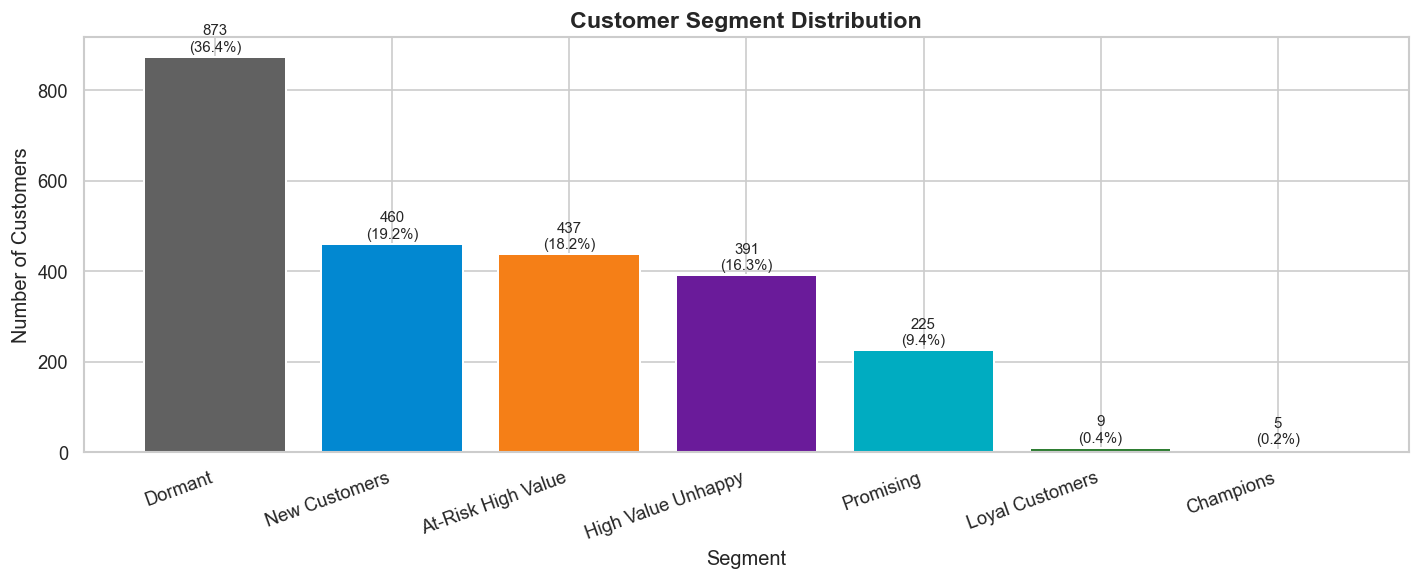

In [40]:
# ── Chart 1: Segment Size ─────────────────────────────────────────────────────
seg_order = rfm['segment'].value_counts().index.tolist()
colors_ordered = [PALETTE.get(s, '#888888') for s in seg_order]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(seg_order, rfm['segment'].value_counts().values,
              color=colors_ordered, edgecolor='white', linewidth=1.2)
for bar in bars:
    val = bar.get_height()
    pct = val / len(rfm) * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + len(rfm)*0.003,
           f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Segment')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('charts/01_segment_distribution.png', bbox_inches='tight')
plt.show()

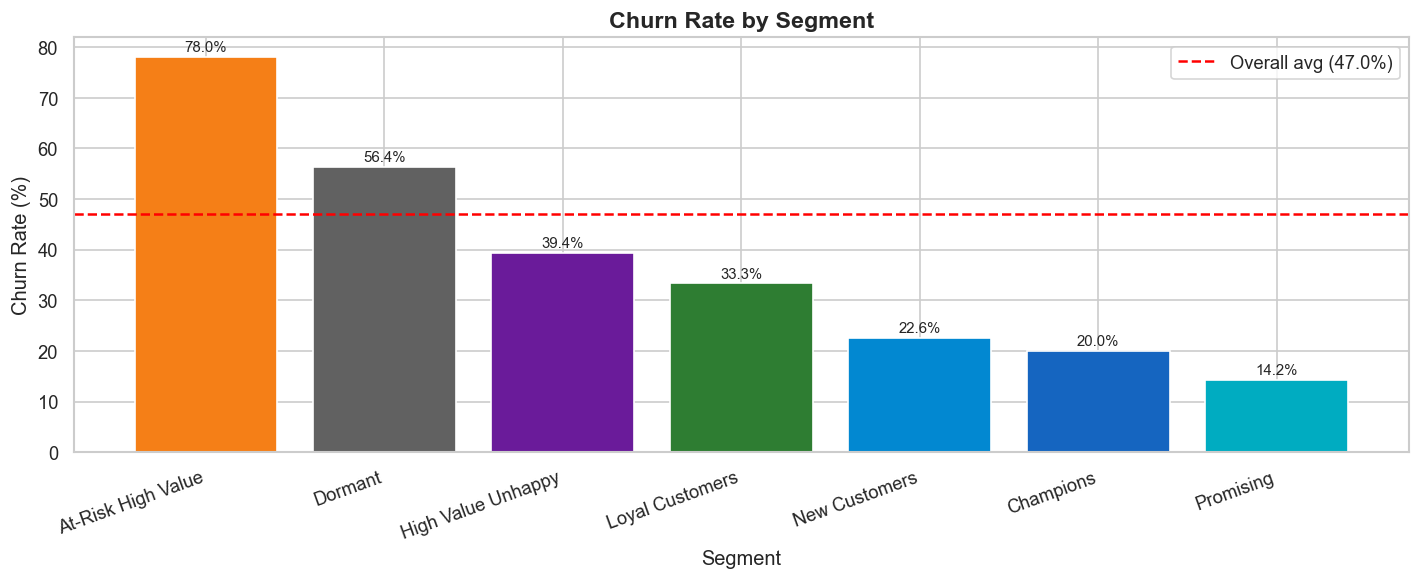

,segment,churn_rate,count,churn_rate_pct
0,At-Risk High Value,0.780,437,78.032
2,Dormant,0.564,873,56.357
3,High Value Unhappy,0.394,391,39.386
4,Loyal Customers,0.333,9,33.333
5,New Customers,0.226,460,22.609
1,Champions,0.200,5,20.000
6,Promising,0.142,225,14.222


In [41]:
# ── Chart 2: Churn Rate by Segment ───────────────────────────────────────────
if 'churn_label' in rfm.columns:
    churn_by_seg = rfm.groupby('segment')['churn_label'].agg(['mean', 'count']).reset_index()
    churn_by_seg.columns = ['segment', 'churn_rate', 'count']
    churn_by_seg['churn_rate_pct'] = churn_by_seg['churn_rate'] * 100
    churn_by_seg = churn_by_seg.sort_values('churn_rate_pct', ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_c = [PALETTE.get(s, '#888888') for s in churn_by_seg['segment']]
    bars = ax.bar(churn_by_seg['segment'], churn_by_seg['churn_rate_pct'],
                  color=colors_c, edgecolor='white')
    overall_churn = rfm['churn_label'].mean() * 100
    ax.axhline(overall_churn, color='red', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall_churn:.1f}%)')
    for bar, (_, row) in zip(bars, churn_by_seg.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f"{row['churn_rate_pct']:.1f}%", ha='center', va='bottom', fontsize=9)
    ax.set_title('Churn Rate by Segment', fontsize=14, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('Segment')
    ax.legend()
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig('charts/02_churn_rate_by_segment.png', bbox_inches='tight')
    plt.show()
    display(churn_by_seg)

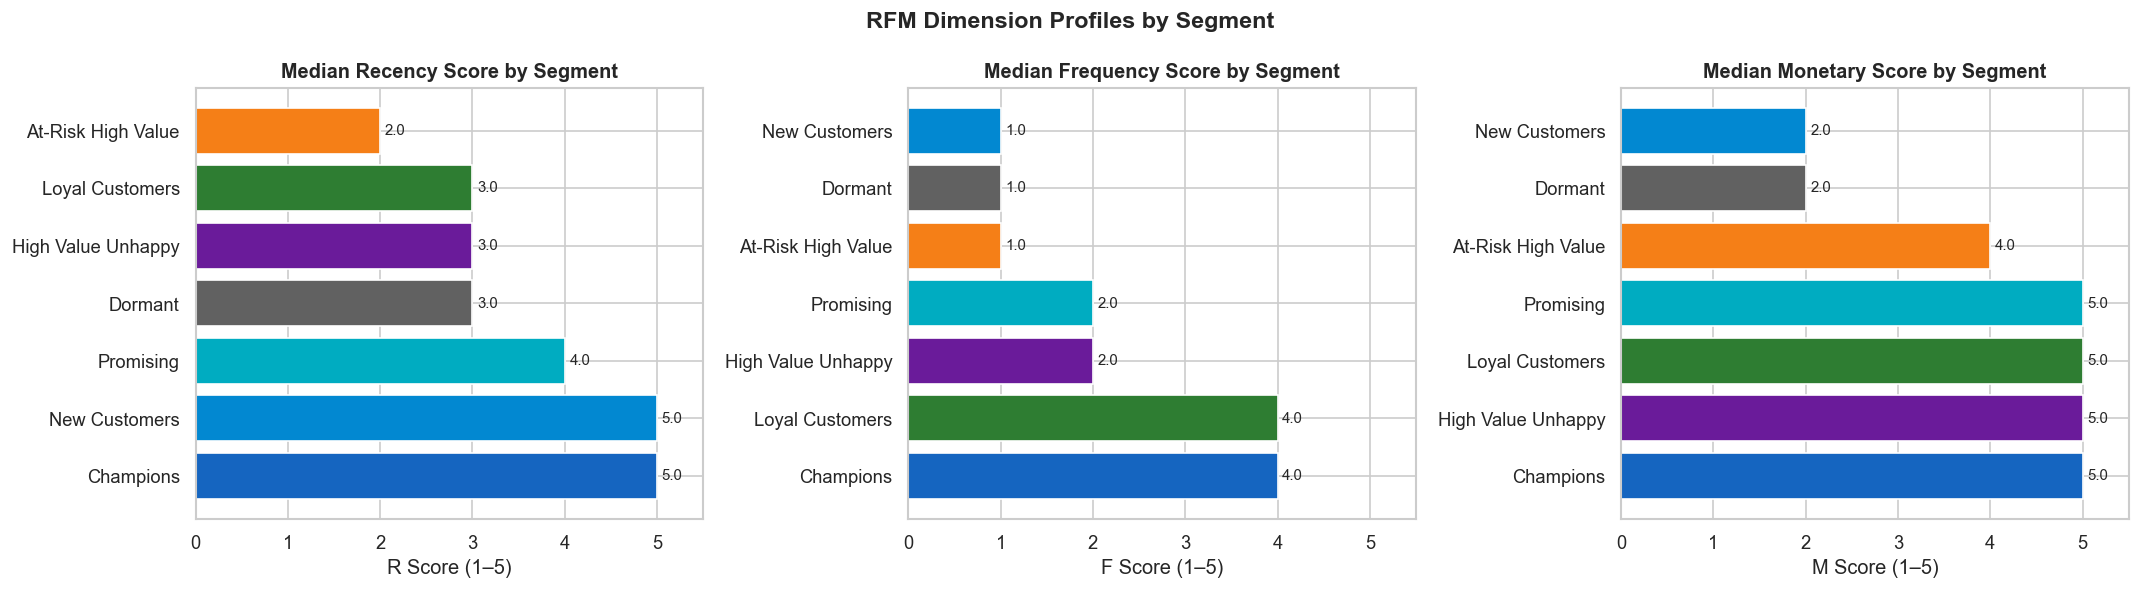

In [42]:
# ── Chart 3: RFM Score Box Plot by Segment ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (dim, label) in enumerate([('R', 'Recency Score'), ('F', 'Frequency Score'), ('M', 'Monetary Score')]):
    seg_r = rfm.groupby('segment')[dim].median().sort_values(ascending=False)
    colors_box = [PALETTE.get(s, '#888888') for s in seg_r.index]
    axes[i].barh(seg_r.index, seg_r.values, color=colors_box, edgecolor='white')
    axes[i].set_title(f'Median {label} by Segment', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{dim} Score (1–5)')
    axes[i].set_xlim(0, 5.5)
    for j, (seg, val) in enumerate(seg_r.items()):
        axes[i].text(val + 0.05, j, f'{val:.1f}', va='center', fontsize=9)

plt.suptitle('RFM Dimension Profiles by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_rfm_profiles_by_segment.png', bbox_inches='tight')
plt.show()

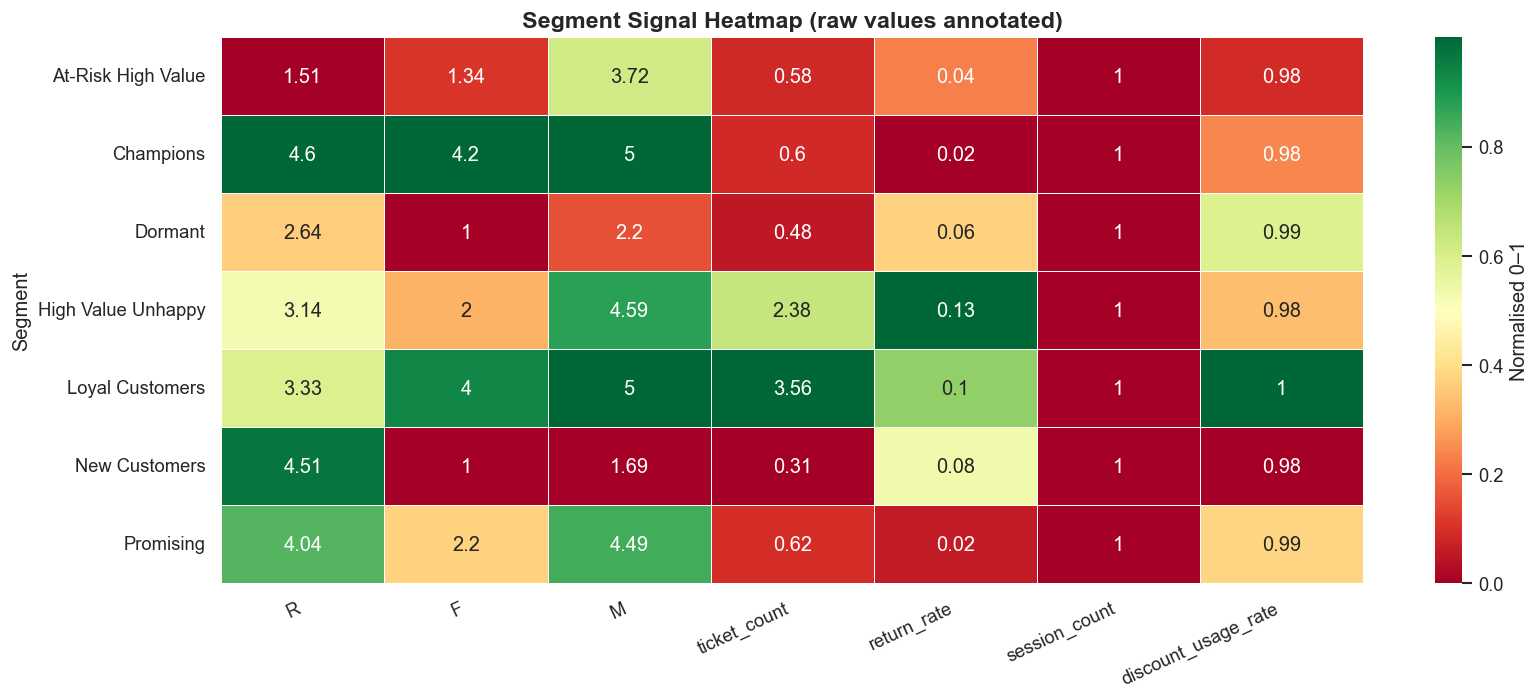

In [43]:
# ── Chart 4: Behavioural Signal Heatmap by Segment ───────────────────────────
signal_cols = ['R', 'F', 'M']
for col in ['ticket_count', 'return_rate', 'session_count', 'discount_usage_rate']:
    if col in rfm.columns:
        signal_cols.append(col)

seg_profile = rfm.groupby('segment')[signal_cols].mean()

# Normalise to 0-1 for heatmap
seg_profile_norm = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(seg_profile_norm, annot=seg_profile.round(2), fmt='g',
            cmap='RdYlGn', ax=ax, linewidths=0.5, cbar_kws={'label': 'Normalised 0–1'})
ax.set_title('Segment Signal Heatmap (raw values annotated)', fontsize=14, fontweight='bold')
ax.set_ylabel('Segment')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('charts/04_segment_heatmap.png', bbox_inches='tight')
plt.show()

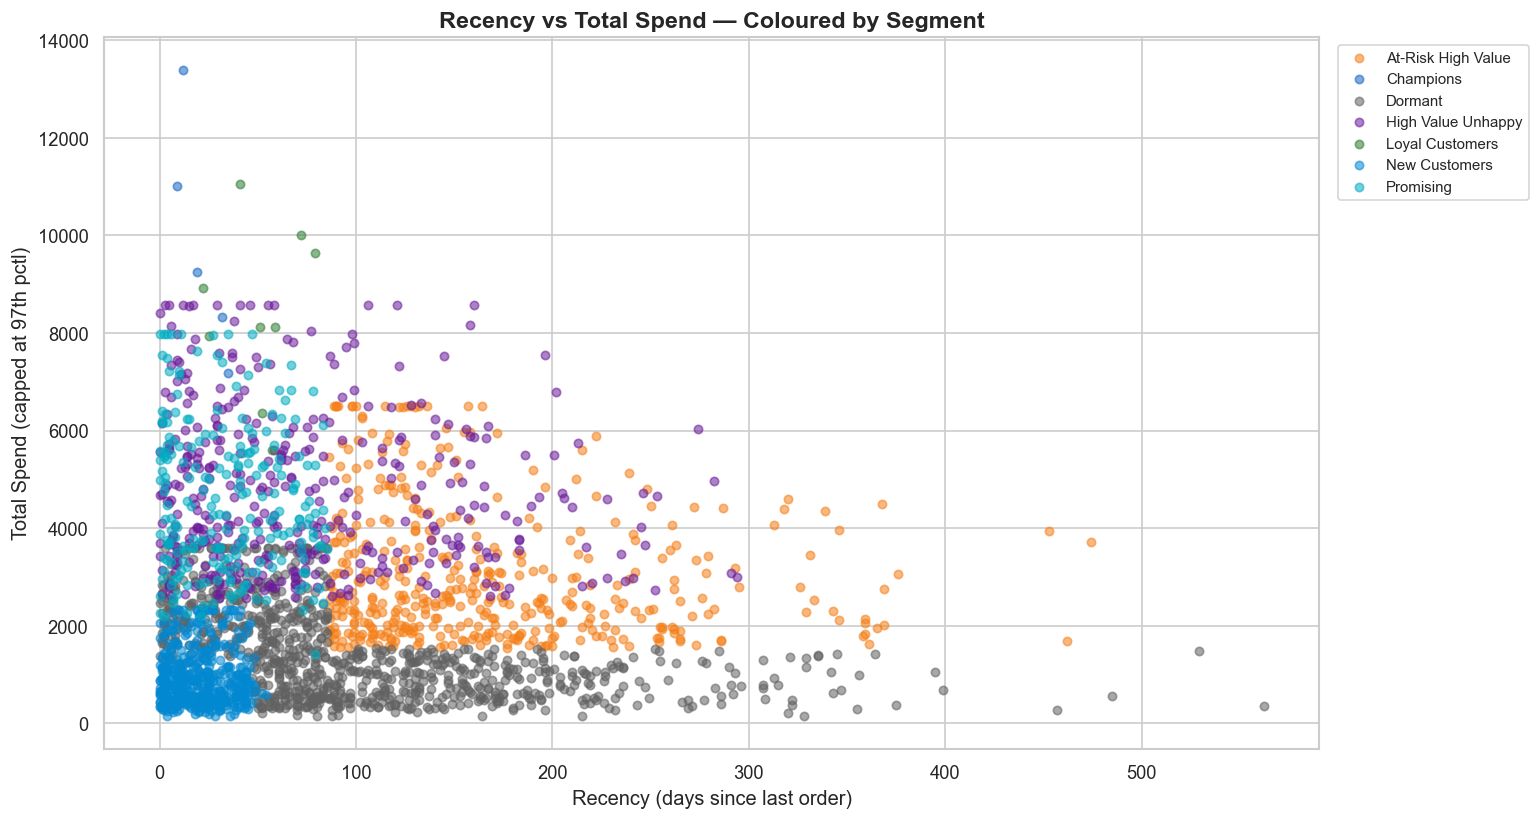

In [44]:
# ── Chart 5: Recency vs Monetary Scatter (coloured by segment) ───────────────
if 'monetary' in rfm.columns:
    fig, ax = plt.subplots(figsize=(13, 7))
    
    for seg, grp in rfm.groupby('segment'):
        cap_monetary = grp['monetary'].clip(upper=grp['monetary'].quantile(0.97))
        ax.scatter(grp['recency_days'], cap_monetary,
                   label=seg, alpha=0.55, s=25,
                   color=PALETTE.get(seg, '#888888'))
    
    ax.set_title('Recency vs Total Spend — Coloured by Segment', fontsize=14, fontweight='bold')
    ax.set_xlabel('Recency (days since last order)')
    ax.set_ylabel('Total Spend (capped at 97th pctl)')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig('charts/05_recency_vs_monetary_scatter.png', bbox_inches='tight')
    plt.show()

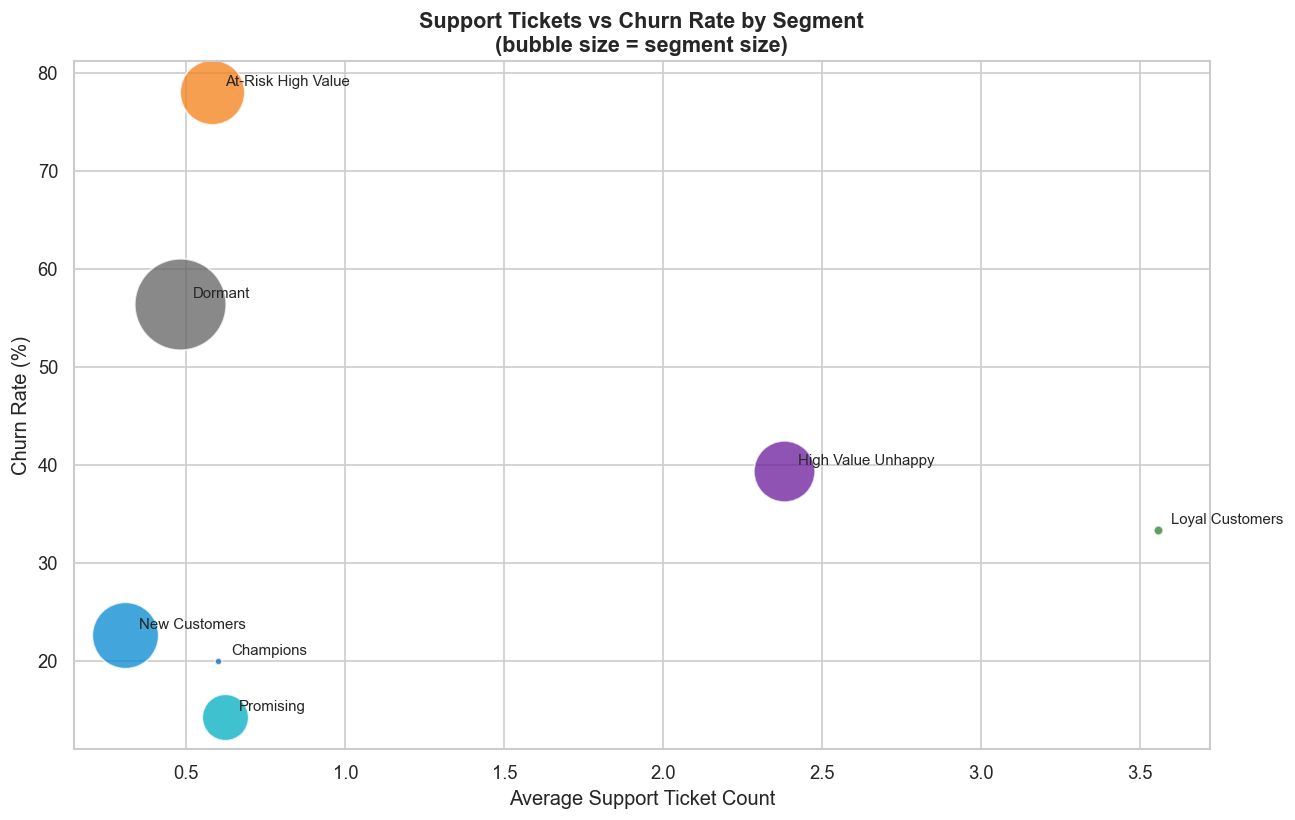

In [45]:
# ── Chart 6: Ticket Count vs Churn Rate Bubble Chart ────────────────────────
if 'ticket_count' in rfm.columns and 'churn_label' in rfm.columns:
    bubble = rfm.groupby('segment').agg(
        churn_rate=('churn_label', 'mean'),
        avg_tickets=('ticket_count', 'mean'),
        count=(CUST_ID, 'count')
    ).reset_index()
    
    fig, ax = plt.subplots(figsize=(11, 7))
    for _, row in bubble.iterrows():
        ax.scatter(row['avg_tickets'], row['churn_rate'] * 100,
                   s=row['count'] / max(bubble['count']) * 3000,
                   color=PALETTE.get(row['segment'], '#888888'),
                   alpha=0.75, edgecolors='white', linewidth=1)
        ax.annotate(row['segment'], (row['avg_tickets'], row['churn_rate'] * 100),
                   textcoords='offset points', xytext=(8, 4), fontsize=9)
    
    ax.set_xlabel('Average Support Ticket Count')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title('Support Tickets vs Churn Rate by Segment\n(bubble size = segment size)',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('charts/06_tickets_vs_churn_bubble.png', bbox_inches='tight')
    plt.show()

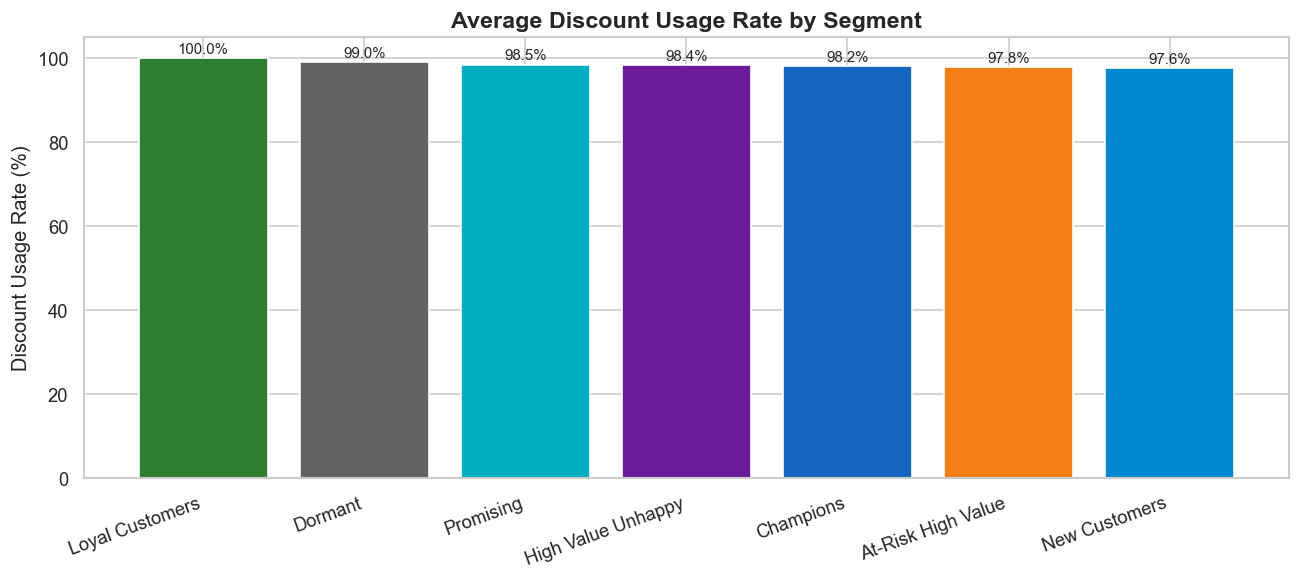

In [46]:
# ── Chart 7: Discount Usage Rate by Segment ──────────────────────────────────
if 'discount_usage_rate' in rfm.columns:
    disc_by_seg = rfm.groupby('segment')['discount_usage_rate'].mean().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(disc_by_seg.index, disc_by_seg.values * 100,
                  color=[PALETTE.get(s, '#888888') for s in disc_by_seg.index],
                  edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title('Average Discount Usage Rate by Segment', fontsize=14, fontweight='bold')
    ax.set_ylabel('Discount Usage Rate (%)')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig('charts/07_discount_usage_by_segment.png', bbox_inches='tight')
    plt.show()

---
## 7. Segment Summary Table

In [47]:
# Build summary table
summary_agg = {
    'count': (CUST_ID, 'count'),
    'median_recency_days': ('recency_days', 'median'),
    'median_frequency': ('frequency', 'median'),
}
if 'monetary' in rfm.columns:
    summary_agg['median_monetary'] = ('monetary', 'median')
if 'churn_label' in rfm.columns:
    summary_agg['churn_rate'] = ('churn_label', 'mean')
if 'ticket_count' in rfm.columns:
    summary_agg['avg_tickets'] = ('ticket_count', 'mean')
if 'return_rate' in rfm.columns:
    summary_agg['avg_return_rate'] = ('return_rate', 'mean')
if 'session_count' in rfm.columns:
    summary_agg['avg_sessions'] = ('session_count', 'mean')
if 'discount_usage_rate' in rfm.columns:
    summary_agg['avg_discount_rate'] = ('discount_usage_rate', 'mean')

seg_summary = rfm.groupby('segment').agg(**summary_agg).reset_index()
seg_summary = seg_summary.sort_values('count', ascending=False)

# Format percentages
for col in ['churn_rate', 'avg_return_rate', 'avg_discount_rate']:
    if col in seg_summary.columns:
        seg_summary[col] = (seg_summary[col] * 100).round(1).astype(str) + '%'

display(seg_summary)
seg_summary.to_csv('outputs/segment_summary.csv', index=False)
print('Saved outputs/segment_summary.csv')

,segment,count,median_recency_days,median_frequency,median_monetary,churn_rate,avg_tickets,avg_return_rate,avg_sessions,avg_discount_rate
2,Dormant,873,79.000,2.000,1252.030,56.4%,0.480,5.9%,1.000,99.0%
5,New Customers,460,20.000,1.000,806.335,22.6%,0.309,7.7%,1.000,97.6%
0,At-Risk High Value,437,147.000,4.000,2579.220,78.0%,0.581,4.3%,1.000,97.8%
3,High Value Unhappy,391,57.000,6.000,4444.300,39.4%,2.381,12.8%,1.000,98.4%
6,Promising,225,33.000,6.000,4265.330,14.2%,0.622,2.5%,1.000,98.5%
4,Loyal Customers,9,52.000,11.000,8130.160,33.3%,3.556,9.8%,1.000,100.0%
1,Champions,5,19.000,11.000,9241.950,20.0%,0.600,1.8%,1.000,98.2%


Saved outputs/segment_summary.csv


---
## 8. Export segments.csv

In [48]:
# Select columns for segments.csv
export_cols = [CUST_ID, 'segment', 'R', 'F', 'M', 'RFM_Score',
               'recency_days', 'frequency']
if 'monetary' in rfm.columns:            export_cols.append('monetary')
if 'avg_order_value' in rfm.columns:     export_cols.append('avg_order_value')
if 'ticket_count' in rfm.columns:        export_cols.append('ticket_count')
if 'unresolved_tickets' in rfm.columns:  export_cols.append('unresolved_tickets')
if 'return_rate' in rfm.columns:         export_cols.append('return_rate')
if 'session_count' in rfm.columns:       export_cols.append('session_count')
if 'discount_usage_rate' in rfm.columns: export_cols.append('discount_usage_rate')
if 'churn_label' in rfm.columns:         export_cols.append('churn_label')

export_cols = [c for c in export_cols if c in rfm.columns]  # safety filter
segments_df = rfm[export_cols].copy()
segments_df.to_csv('segments.csv', index=False)
print(f'segments.csv saved: {segments_df.shape[0]:,} customers × {segments_df.shape[1]} columns')
display(segments_df.head(10))

segments.csv saved: 2,400 customers × 16 columns


,customer_id,segment,R,F,M,RFM_Score,recency_days,frequency,monetary,avg_order_value,ticket_count,unresolved_tickets,return_rate,session_count,discount_usage_rate,churn_label
0,CUST00001,High Value Unhappy,2.000,2.000,4.000,8.000,107,6,2955.570,492.595,2.000,0,0.167,1,1.000,1
1,CUST00002,New Customers,4.000,1.000,1.000,6.000,40,1,581.000,581.000,1.000,0,0.000,1,1.000,0
2,CUST00003,Dormant,1.000,1.000,1.000,3.000,171,1,649.980,649.980,0.000,0,0.000,1,1.000,1
3,CUST00004,At-Risk High Value,2.000,1.000,3.000,6.000,131,1,1604.040,1604.040,0.000,0,0.000,1,1.000,1
4,CUST00005,Dormant,4.000,1.000,3.000,8.000,38,4,2550.910,637.727,1.000,0,0.000,1,1.000,0
5,CUST00006,High Value Unhappy,3.000,2.000,4.000,9.000,51,5,3770.160,754.032,2.000,0,0.200,1,1.000,0
6,CUST00007,New Customers,5.000,1.000,1.000,7.000,3,1,719.330,719.330,0.000,0,0.000,1,1.000,0
7,CUST00008,Dormant,3.000,1.000,4.000,8.000,47,4,2747.330,686.832,1.000,0,0.000,1,1.000,0
8,CUST00009,New Customers,4.000,1.000,1.000,6.000,31,1,376.850,376.850,0.000,0,0.000,1,1.000,0
9,CUST00010,New Customers,5.000,1.000,1.000,7.000,9,1,636.800,636.800,0.000,0,0.000,1,1.000,0


---
## 9. Manual Review: Edge Cases

The following code identifies 10 customers whose segment assignment is non-obvious due to conflicting signals. These are exported and discussed in `manual_review_cases.md`.

In [49]:
# Find edge-case customers
edge_cases = pd.DataFrame()

# Case type 1: High monetary but high churn risk (high value at risk)
if 'monetary' in rfm.columns and 'churn_label' in rfm.columns:
    monetary_75 = rfm['monetary'].quantile(0.75)
    type1 = rfm[(rfm['monetary'] >= monetary_75) & (rfm['churn_label'] == 1)].head(3)
    type1 = type1.copy()
    type1['edge_case_type'] = 'High Value + Churned'
    edge_cases = pd.concat([edge_cases, type1])

# Case type 2: High discount usage + still loyal (discount seekers who stayed)
if 'discount_usage_rate' in rfm.columns:
    type2 = rfm[(rfm['discount_usage_rate'] >= 0.7) & (rfm['F'] >= 4)].head(2)
    type2 = type2.copy()
    type2['edge_case_type'] = 'Heavy Discounter but Frequent'
    edge_cases = pd.concat([edge_cases, type2])

# Case type 3: High ticket count + no churn (complained but stayed)
if 'ticket_count' in rfm.columns and 'churn_label' in rfm.columns:
    type3 = rfm[(rfm['ticket_count'] >= 3) & (rfm['churn_label'] == 0)].head(2)
    type3 = type3.copy()
    type3['edge_case_type'] = 'High Complaints but Retained'
    edge_cases = pd.concat([edge_cases, type3])

# Case type 4: Recent signup + high return rate
if 'return_rate' in rfm.columns:
    type4 = rfm[(rfm['days_since_signup'] <= 60) & (rfm['return_rate'] >= 0.3)].head(2)
    type4 = type4.copy()
    type4['edge_case_type'] = 'New Customer + High Returns'
    edge_cases = pd.concat([edge_cases, type4])

# Case type 5: Zero sessions but recent purchaser
if 'session_count' in rfm.columns:
    type5 = rfm[(rfm['session_count'] == 0) & (rfm['R'] >= 4)].head(1)
    type5 = type5.copy()
    type5['edge_case_type'] = 'Recent Buyer but Zero App Sessions'
    edge_cases = pd.concat([edge_cases, type5])

# Ensure we have at least 10
if len(edge_cases) < 10:
    shortfall = 10 - len(edge_cases)
    extra = rfm[~rfm[CUST_ID].isin(edge_cases[CUST_ID])].head(shortfall).copy()
    extra['edge_case_type'] = 'Mixed Signals'
    edge_cases = pd.concat([edge_cases, extra])

edge_cases = edge_cases.head(10).reset_index(drop=True)
display_cols = [c for c in [CUST_ID, 'segment', 'edge_case_type', 'R', 'F', 'M',
                              'recency_days', 'frequency', 'ticket_count',
                              'return_rate', 'session_count', 'discount_usage_rate',
                              'churn_label'] if c in edge_cases.columns]
display(edge_cases[display_cols])
edge_cases[display_cols].to_csv('outputs/edge_cases.csv', index=False)
print('Saved outputs/edge_cases.csv')

,customer_id,segment,edge_case_type,R,F,M,recency_days,frequency,ticket_count,return_rate,session_count,discount_usage_rate,churn_label
0,CUST00020,At-Risk High Value,High Value + Churned,1.000,1.000,5.000,368,3,1.000,0.000,1,1.000,1
1,CUST00025,High Value Unhappy,High Value + Churned,1.000,2.000,5.000,165,7,3.000,0.000,1,1.000,1
2,CUST00051,High Value Unhappy,High Value + Churned,1.000,1.000,5.000,210,4,2.000,0.000,1,1.000,1
3,CUST00014,Loyal Customers,Heavy Discounter but Frequent,3.000,4.000,5.000,51,11,2.000,0.000,1,1.000,0
4,CUST00088,At-Risk High Value,Heavy Discounter but Frequent,2.000,4.000,5.000,98,12,1.000,0.000,1,1.000,1
5,CUST00034,High Value Unhappy,High Complaints but Retained,3.000,2.000,4.000,50,6,3.000,0.000,1,1.000,0
6,CUST00042,High Value Unhappy,High Complaints but Retained,2.000,3.000,5.000,87,9,6.000,0.222,1,1.000,0
7,CUST00251,New Customers,New Customer + High Returns,4.000,1.000,2.000,41,1,1.000,1.000,1,1.000,1
8,CUST00310,New Customers,New Customer + High Returns,4.000,1.000,1.000,22,1,1.000,1.000,1,1.000,0
9,CUST00001,High Value Unhappy,Mixed Signals,2.000,2.000,4.000,107,6,2.000,0.167,1,1.000,1


Saved outputs/edge_cases.csv


In [50]:
# ── Final summary ─────────────────────────────────────────────────────────────
charts_list = sorted(os.listdir('charts'))
print(f'Charts saved ({len(charts_list)}): {charts_list}')
print(f'\nsegments.csv: {len(segments_df):,} customers across {rfm["segment"].nunique()} segments')
print('\nPart 2 complete. Proceed to Part 3: Churn Prediction Model.')

Charts saved (7): ['01_segment_distribution.png', '02_churn_rate_by_segment.png', '03_rfm_profiles_by_segment.png', '04_segment_heatmap.png', '05_recency_vs_monetary_scatter.png', '06_tickets_vs_churn_bubble.png', '07_discount_usage_by_segment.png']

segments.csv: 2,400 customers across 7 segments

Part 2 complete. Proceed to Part 3: Churn Prediction Model.
